# 03b_execution_aware_backtest

## Goal

This notebook connects:

- the **strategy decision layer** from `03a_strategy_decision_generator.ipynb`
- the **L2 top-N reconstructed order-book snapshots** from `01_reconstruct_l2_book.ipynb`

to produce an **execution-aware after-cost backtest**.

## What this notebook does

1. Load strategy decisions for the target date
2. Load reconstructed top20 order-book snapshots for the same date
3. Forward-align decision timestamps to executable book timestamps
4. Simulate taker execution using fixed-notional sizing
5. Build trade/fill logs
6. Compute after-cost realized PnL
7. Summarize performance and size sensitivity

## Version 1 assumptions

- single date first
- fixed-notional sizing
- taker-only execution
- forward alignment (`book_time >= decision_time`)
- partial fills accepted
- direction is determined by `signal` in {-1, 0, +1}

In [35]:
# =========================================
# 1. Imports
# =========================================

from pathlib import Path
from typing import List, Dict, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Configuration

Edit this section first.

In [79]:
# =========================================
# 1b. User Config
# =========================================

from pathlib import Path

DATA_ROOT = Path("/Volumes/profit")
RECON_OUTPUT_ROOT = DATA_ROOT / "bitcoin_ticks" / "reconstructed_outputs" / "spot" / "btcusdt"
STRATEGY_OUTPUT_ROOT = DATA_ROOT / "bitcoin_ticks" / "strategy_outputs"
BACKTEST_OUTPUT_ROOT = DATA_ROOT / "bitcoin_ticks" / "backtest_outputs"
BACKTEST_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

TARGET_DATE = "20251123"

STRATEGY_DECISION_FILE = STRATEGY_OUTPUT_ROOT / f"strategy_decisions_{TARGET_DATE}.parquet"

TOP_N = 20
TRADE_NOTIONAL = 1000.0

# Binance Spot VIP0 standard taker fee
TAKER_FEE_BPS = 10.0

FIGSIZE = (12, 5)

# signal-strength diagnosis / sizing thresholds
ENTRY_Z = 1.5
STRONG_Z = 2.75

In [37]:
# =========================================
# 1c. Path sanity checks
# =========================================

print("RECON_OUTPUT_ROOT exists   :", RECON_OUTPUT_ROOT.exists(), RECON_OUTPUT_ROOT)
print("STRATEGY_DECISION_FILE     :", STRATEGY_DECISION_FILE.exists(), STRATEGY_DECISION_FILE)
print("BACKTEST_OUTPUT_ROOT       :", BACKTEST_OUTPUT_ROOT)

RECON_OUTPUT_ROOT exists   : True /Volumes/profit/bitcoin_ticks/reconstructed_outputs/spot/btcusdt
STRATEGY_DECISION_FILE     : True /Volumes/profit/bitcoin_ticks/strategy_outputs/strategy_decisions_20251123.parquet
BACKTEST_OUTPUT_ROOT       : /Volumes/profit/bitcoin_ticks/backtest_outputs


In [38]:
# 2. Load strategy decisions

In [39]:
# =========================================
# 2. Load strategy decisions
# =========================================

decisions = pd.read_parquet(STRATEGY_DECISION_FILE) if STRATEGY_DECISION_FILE.exists() else pd.DataFrame()

print("decisions shape:", decisions.shape)
if len(decisions) > 0:
    display(decisions.head(10))
    print("decision columns:")
    print(list(decisions.columns))

decisions shape: (1441, 8)


,decision_time,date,basis_z,basis_regime_flag,pred_vol_30m,pred_vol_filter_flag,raw_basis_signal,signal
0,2025-11-23 00:00:00+00:00,20251123,NaN,False,NaN,False,0,0
1,2025-11-23 00:01:00+00:00,20251123,NaN,False,NaN,False,0,0
2,2025-11-23 00:02:00+00:00,20251123,NaN,False,NaN,False,0,0
3,2025-11-23 00:03:00+00:00,20251123,NaN,False,NaN,False,0,0
4,2025-11-23 00:04:00+00:00,20251123,NaN,False,NaN,False,0,0
5,2025-11-23 00:05:00+00:00,20251123,NaN,False,NaN,False,0,0
6,2025-11-23 00:06:00+00:00,20251123,NaN,False,NaN,False,0,0
7,2025-11-23 00:07:00+00:00,20251123,NaN,False,NaN,False,0,0
8,2025-11-23 00:08:00+00:00,20251123,NaN,False,NaN,False,0,0
9,2025-11-23 00:09:00+00:00,20251123,NaN,False,NaN,False,0,0


decision columns:
['decision_time', 'date', 'basis_z', 'basis_regime_flag', 'pred_vol_30m', 'pred_vol_filter_flag', 'raw_basis_signal', 'signal']


# 3. Discover and load top20 reconstructed book snapshots

We load all hourly top20 parquet files for the target date.

In [40]:
# =========================================
# 3. Discover hourly top20 parquet files
# =========================================

def discover_topn_parquet_files(output_root: Path) -> pd.DataFrame:
    rows = []

    for p in sorted(output_root.glob("book_top20_sampled_*.parquet")):
        name = p.name
        stem = name.replace(".parquet", "")
        parts = stem.split("_")

        # expected pattern: book_top20_sampled_YYYYMMDD_HH
        if len(parts) < 5:
            continue

        date_str = parts[-2]
        hour_str = parts[-1]

        if not (date_str.isdigit() and len(date_str) == 8):
            continue
        if not (hour_str.isdigit() and len(hour_str) == 2):
            continue

        rows.append({
            "path": str(p),
            "date": date_str,
            "hour": hour_str,
            "session_id": f"{date_str}_{hour_str}",
        })

    return pd.DataFrame(rows)

topn_file_map = discover_topn_parquet_files(RECON_OUTPUT_ROOT)

print("topn_file_map shape:", topn_file_map.shape)
display(topn_file_map.head(20))

topn_file_map shape: (184, 4)


,path,date,hour,session_id
0,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251030,00,20251030_00
1,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251030,01,20251030_01
2,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251030,02,20251030_02
3,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251030,03,20251030_03
4,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251030,04,20251030_04
5,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251030,05,20251030_05
6,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251030,06,20251030_06
7,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251030,07,20251030_07
8,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251030,08,20251030_08
9,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251030,09,20251030_09


In [41]:
# =========================================
# 3b. Load one day of top20 snapshots
# =========================================

topn_day_files = topn_file_map[topn_file_map["date"] == TARGET_DATE].copy()

print("TARGET_DATE:", TARGET_DATE)
print("n files for date:", len(topn_day_files))
display(topn_day_files.head(10))

topn_day = pd.concat(
    [pd.read_parquet(p) for p in topn_day_files["path"]],
    ignore_index=True
) if len(topn_day_files) > 0 else pd.DataFrame()

print("topn_day shape:", topn_day.shape)

if len(topn_day) > 0:
    display(topn_day.head(5))
    print("topn_day columns:")
    print(list(topn_day.columns))

TARGET_DATE: 20251123
n files for date: 24


,path,date,hour,session_id
160,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251123,00,20251123_00
161,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251123,01,20251123_01
162,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251123,02,20251123_02
163,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251123,03,20251123_03
164,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251123,04,20251123_04
165,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251123,05,20251123_05
166,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251123,06,20251123_06
167,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251123,07,20251123_07
168,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251123,08,20251123_08
169,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251123,09,20251123_09


topn_day shape: (89795, 88)


,event_time,last_update_id,bid_px_1,bid_sz_1,ask_px_1,ask_sz_1,bid_px_2,bid_sz_2,ask_px_2,ask_sz_2,...,bid_px_20,bid_sz_20,ask_px_20,ask_sz_20,date,hour,session_id,segment_id,snapshot_file,source_file
0,1763856072014,81541430648,84685.57,7.75850,84685.58,1.68930,84685.34,0.00014,84685.59,0.00091,...,84680.00,0.00006,84689.08,0.16773,20251123,00,20251123_00,0,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...
1,1763856073014,81541430819,84685.57,7.76288,84685.58,1.71318,84685.34,0.00014,84685.59,0.00091,...,84680.00,0.00006,84689.07,0.00014,20251123,00,20251123_00,0,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...
2,1763856074014,81541431063,84685.57,7.76410,84685.58,1.73542,84685.56,0.00056,84685.59,0.00091,...,84681.00,0.06000,84688.99,0.00006,20251123,00,20251123_00,0,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...
3,1763856075014,81541431213,84685.57,8.06477,84685.58,1.72445,84685.56,0.00063,84685.59,0.00091,...,84681.54,0.01201,84689.08,0.16104,20251123,00,20251123_00,0,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...
4,1763856076014,81541431471,84685.57,7.54412,84685.58,1.57892,84685.56,0.00049,84685.59,0.00091,...,84681.54,0.00006,84689.07,0.00014,20251123,00,20251123_00,0,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...


topn_day columns:
['event_time', 'last_update_id', 'bid_px_1', 'bid_sz_1', 'ask_px_1', 'ask_sz_1', 'bid_px_2', 'bid_sz_2', 'ask_px_2', 'ask_sz_2', 'bid_px_3', 'bid_sz_3', 'ask_px_3', 'ask_sz_3', 'bid_px_4', 'bid_sz_4', 'ask_px_4', 'ask_sz_4', 'bid_px_5', 'bid_sz_5', 'ask_px_5', 'ask_sz_5', 'bid_px_6', 'bid_sz_6', 'ask_px_6', 'ask_sz_6', 'bid_px_7', 'bid_sz_7', 'ask_px_7', 'ask_sz_7', 'bid_px_8', 'bid_sz_8', 'ask_px_8', 'ask_sz_8', 'bid_px_9', 'bid_sz_9', 'ask_px_9', 'ask_sz_9', 'bid_px_10', 'bid_sz_10', 'ask_px_10', 'ask_sz_10', 'bid_px_11', 'bid_sz_11', 'ask_px_11', 'ask_sz_11', 'bid_px_12', 'bid_sz_12', 'ask_px_12', 'ask_sz_12', 'bid_px_13', 'bid_sz_13', 'ask_px_13', 'ask_sz_13', 'bid_px_14', 'bid_sz_14', 'ask_px_14', 'ask_sz_14', 'bid_px_15', 'bid_sz_15', 'ask_px_15', 'ask_sz_15', 'bid_px_16', 'bid_sz_16', 'ask_px_16', 'ask_sz_16', 'bid_px_17', 'bid_sz_17', 'ask_px_17', 'ask_sz_17', 'bid_px_18', 'bid_sz_18', 'ask_px_18', 'ask_sz_18', 'bid_px_19', 'bid_sz_19', 'ask_px_19', 'ask_sz_19

In [42]:
# =========================================
# 3c. Normalize / sort top20 snapshots
# =========================================

if len(topn_day) > 0:
    topn_day["event_time"] = pd.to_numeric(topn_day["event_time"])
    topn_day = topn_day.sort_values(["session_id", "event_time"]).reset_index(drop=True)

print("topn_day shape after sort:", topn_day.shape)
if len(topn_day) > 0:
    display(topn_day.head(5))

topn_day shape after sort: (89795, 88)


,event_time,last_update_id,bid_px_1,bid_sz_1,ask_px_1,ask_sz_1,bid_px_2,bid_sz_2,ask_px_2,ask_sz_2,...,bid_px_20,bid_sz_20,ask_px_20,ask_sz_20,date,hour,session_id,segment_id,snapshot_file,source_file
0,1763856072014,81541430648,84685.57,7.75850,84685.58,1.68930,84685.34,0.00014,84685.59,0.00091,...,84680.00,0.00006,84689.08,0.16773,20251123,00,20251123_00,0,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...
1,1763856073014,81541430819,84685.57,7.76288,84685.58,1.71318,84685.34,0.00014,84685.59,0.00091,...,84680.00,0.00006,84689.07,0.00014,20251123,00,20251123_00,0,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...
2,1763856074014,81541431063,84685.57,7.76410,84685.58,1.73542,84685.56,0.00056,84685.59,0.00091,...,84681.00,0.06000,84688.99,0.00006,20251123,00,20251123_00,0,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...
3,1763856075014,81541431213,84685.57,8.06477,84685.58,1.72445,84685.56,0.00063,84685.59,0.00091,...,84681.54,0.01201,84689.08,0.16104,20251123,00,20251123_00,0,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...
4,1763856076014,81541431471,84685.57,7.54412,84685.58,1.57892,84685.56,0.00049,84685.59,0.00091,...,84681.54,0.00006,84689.07,0.00014,20251123,00,20251123_00,0,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...


# 4. Normalize strategy decision timestamps

We need decisions and top20 snapshots on comparable time axes.

In [43]:
# =========================================
# 4. Normalize strategy decision timestamps
# =========================================

if len(decisions) > 0:
    # 03a exported decision_time from datetime-like timestamps
    decisions["decision_time"] = pd.to_datetime(decisions["decision_time"], utc=True)
    decisions["decision_time_ms"] = (decisions["decision_time"].view("int64") // 10**6).astype("int64")

    if "date" not in decisions.columns:
        decisions["date"] = decisions["decision_time"].dt.strftime("%Y%m%d")

print("decisions shape:", decisions.shape)
if len(decisions) > 0:
    display(decisions.head(10))

decisions shape: (1441, 9)


,decision_time,date,basis_z,basis_regime_flag,pred_vol_30m,pred_vol_filter_flag,raw_basis_signal,signal,decision_time_ms
0,2025-11-23 00:00:00+00:00,20251123,NaN,False,NaN,False,0,0,1763856000000
1,2025-11-23 00:01:00+00:00,20251123,NaN,False,NaN,False,0,0,1763856060000
2,2025-11-23 00:02:00+00:00,20251123,NaN,False,NaN,False,0,0,1763856120000
3,2025-11-23 00:03:00+00:00,20251123,NaN,False,NaN,False,0,0,1763856180000
4,2025-11-23 00:04:00+00:00,20251123,NaN,False,NaN,False,0,0,1763856240000
5,2025-11-23 00:05:00+00:00,20251123,NaN,False,NaN,False,0,0,1763856300000
6,2025-11-23 00:06:00+00:00,20251123,NaN,False,NaN,False,0,0,1763856360000
7,2025-11-23 00:07:00+00:00,20251123,NaN,False,NaN,False,0,0,1763856420000
8,2025-11-23 00:08:00+00:00,20251123,NaN,False,NaN,False,0,0,1763856480000
9,2025-11-23 00:09:00+00:00,20251123,NaN,False,NaN,False,0,0,1763856540000


# 5. Book helpers and execution functions

This notebook is independent from 02, so we reimplement the key execution helpers here.

In [44]:
# =========================================
# 5. Book helpers
# =========================================

def extract_bid_levels(row: pd.Series, n: int = 20) -> List[Tuple[float, float]]:
    levels = []
    for i in range(1, n + 1):
        px = row.get(f"bid_px_{i}", np.nan)
        sz = row.get(f"bid_sz_{i}", np.nan)
        if pd.notna(px) and pd.notna(sz) and sz > 0:
            levels.append((float(px), float(sz)))
    return levels

def extract_ask_levels(row: pd.Series, n: int = 20) -> List[Tuple[float, float]]:
    levels = []
    for i in range(1, n + 1):
        px = row.get(f"ask_px_{i}", np.nan)
        sz = row.get(f"ask_sz_{i}", np.nan)
        if pd.notna(px) and pd.notna(sz) and sz > 0:
            levels.append((float(px), float(sz)))
    return levels

def row_mid(row: pd.Series) -> float:
    best_bid = row.get("bid_px_1", np.nan)
    best_ask = row.get("ask_px_1", np.nan)
    if pd.isna(best_bid) or pd.isna(best_ask):
        return np.nan
    return 0.5 * (best_bid + best_ask)

In [45]:
# =========================================
# 5b. Notional -> quantity helper
# =========================================

def approx_qty_from_notional(row: pd.Series, notional: float) -> float:
    mid = row_mid(row)
    if pd.isna(mid) or mid <= 0:
        return np.nan
    return float(notional / mid)

In [53]:
# =========================================
# 5c. Taker buy / sell execution
# =========================================

def simulate_taker_buy(row: pd.Series, qty: float, n: int = 20, taker_fee_bps: float = 10.0) -> Dict:
    asks = extract_ask_levels(row, n=n)

    remaining = float(qty)
    filled = 0.0
    notional = 0.0
    levels_used = []

    for px, avail in asks:
        if remaining <= 0:
            break
        take = min(remaining, avail)
        filled += take
        notional += take * px
        levels_used.append((px, take))
        remaining -= take

    avg_fill_price = notional / filled if filled > 0 else np.nan
    best_ask = row.get("ask_px_1", np.nan)
    mid = row_mid(row)

    slippage_vs_mid_bps = np.nan
    slippage_vs_touch_bps = np.nan

    if filled > 0 and pd.notna(mid):
        slippage_vs_mid_bps = 1e4 * (avg_fill_price / mid - 1.0)
    if filled > 0 and pd.notna(best_ask):
        slippage_vs_touch_bps = 1e4 * (avg_fill_price / best_ask - 1.0)

    return {
        "side": "buy",
        "event_time": row.get("event_time"),
        "session_id": row.get("session_id"),
        "target_qty": qty,
        "filled_qty": filled,
        "unfilled_qty": remaining,
        "fully_filled": remaining <= 1e-12,
        "avg_fill_price": avg_fill_price,
        "notional": notional,
        "fee_quote": notional * taker_fee_bps / 1e4,
        "mid": mid,
        "touch": best_ask,
        "n_levels_swept": len(levels_used),
        "levels_used": levels_used,
        "slippage_vs_mid_bps": slippage_vs_mid_bps,
        "slippage_vs_touch_bps": slippage_vs_touch_bps,
        "all_in_cost_vs_mid_bps": slippage_vs_mid_bps + taker_fee_bps if pd.notna(slippage_vs_mid_bps) else np.nan,
        "all_in_cost_vs_touch_bps": slippage_vs_touch_bps + taker_fee_bps if pd.notna(slippage_vs_touch_bps) else np.nan,
    }

def simulate_taker_sell(row: pd.Series, qty: float, n: int = 20, taker_fee_bps: float = 10.0) -> Dict:
    bids = extract_bid_levels(row, n=n)

    remaining = float(qty)
    filled = 0.0
    notional = 0.0
    levels_used = []

    for px, avail in bids:
        if remaining <= 0:
            break
        take = min(remaining, avail)
        filled += take
        notional += take * px
        levels_used.append((px, take))
        remaining -= take

    avg_fill_price = notional / filled if filled > 0 else np.nan
    best_bid = row.get("bid_px_1", np.nan)
    mid = row_mid(row)

    slippage_vs_mid_bps = np.nan
    slippage_vs_touch_bps = np.nan

    if filled > 0 and pd.notna(mid):
        slippage_vs_mid_bps = 1e4 * (1.0 - avg_fill_price / mid)
    if filled > 0 and pd.notna(best_bid):
        slippage_vs_touch_bps = 1e4 * (1.0 - avg_fill_price / best_bid)

    return {
        "side": "sell",
        "event_time": row.get("event_time"),
        "session_id": row.get("session_id"),
        "target_qty": qty,
        "filled_qty": filled,
        "unfilled_qty": remaining,
        "fully_filled": remaining <= 1e-12,
        "avg_fill_price": avg_fill_price,
        "notional": notional,
        "fee_quote": notional * taker_fee_bps / 1e4,
        "mid": mid,
        "touch": best_bid,
        "n_levels_swept": len(levels_used),
        "levels_used": levels_used,
        "slippage_vs_mid_bps": slippage_vs_mid_bps,
        "slippage_vs_touch_bps": slippage_vs_touch_bps,
        "all_in_cost_vs_mid_bps": slippage_vs_mid_bps + taker_fee_bps if pd.notna(slippage_vs_mid_bps) else np.nan,
        "all_in_cost_vs_touch_bps": slippage_vs_touch_bps + taker_fee_bps if pd.notna(slippage_vs_touch_bps) else np.nan,
    }

# 6. Forward-align decisions to executable book snapshots

Rule:
- for each decision timestamp, use the first book snapshot whose `event_time >= decision_time_ms`

In [54]:
# =========================================
# 6. Forward align decisions to book snapshots
# =========================================

def align_decisions_to_books(decisions_df: pd.DataFrame, books_df: pd.DataFrame) -> pd.DataFrame:
    if len(decisions_df) == 0 or len(books_df) == 0:
        return pd.DataFrame()

    left = decisions_df.sort_values("decision_time_ms").copy()
    right = books_df.sort_values("event_time").copy()

    aligned = pd.merge_asof(
        left,
        right,
        left_on="decision_time_ms",
        right_on="event_time",
        direction="forward",
    )

    return aligned

aligned_decisions = align_decisions_to_books(decisions, topn_day)

print("aligned_decisions shape:", aligned_decisions.shape)
if len(aligned_decisions) > 0:
    display(aligned_decisions.head(130))

aligned_decisions shape: (1441, 97)


,decision_time,date_x,basis_z,basis_regime_flag,pred_vol_30m,pred_vol_filter_flag,raw_basis_signal,signal,decision_time_ms,event_time,...,bid_px_20,bid_sz_20,ask_px_20,ask_sz_20,date_y,hour,session_id,segment_id,snapshot_file,source_file
0,2025-11-23 00:00:00+00:00,20251123,NaN,False,NaN,False,0,0,1763856000000,1763856072014,...,84680.00,0.00006,84689.08,0.16773,20251123,00,20251123_00,0,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...
1,2025-11-23 00:01:00+00:00,20251123,NaN,False,NaN,False,0,0,1763856060000,1763856072014,...,84680.00,0.00006,84689.08,0.16773,20251123,00,20251123_00,0,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...
2,2025-11-23 00:02:00+00:00,20251123,NaN,False,NaN,False,0,0,1763856120000,1763856120014,...,84787.00,0.00007,84801.42,0.78087,20251123,00,20251123_00,0,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...
3,2025-11-23 00:03:00+00:00,20251123,NaN,False,NaN,False,0,0,1763856180000,1763856180014,...,84867.72,0.00006,84880.43,0.00014,20251123,00,20251123_00,0,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...
4,2025-11-23 00:04:00+00:00,20251123,NaN,False,NaN,False,0,0,1763856240000,1763856240314,...,84938.85,0.03294,84955.89,0.00014,20251123,00,20251123_00,0,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,2025-11-23 02:05:00+00:00,20251123,0.884101,True,-10.827250,True,0,0,1763863500000,1763863500014,...,85981.97,0.01068,85995.11,0.70274,20251123,02,20251123_02,0,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...
126,2025-11-23 02:06:00+00:00,20251123,-0.551980,True,-10.769203,True,0,0,1763863560000,1763863560014,...,86000.16,0.38396,86011.68,0.00561,20251123,02,20251123_02,0,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...
127,2025-11-23 02:07:00+00:00,20251123,-0.127111,True,-10.699713,True,0,0,1763863620000,1763863620214,...,85996.00,0.00240,86007.44,0.00007,20251123,02,20251123_02,0,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...
128,2025-11-23 02:08:00+00:00,20251123,-0.881489,True,-10.692462,True,0,0,1763863680000,1763863680514,...,85832.18,0.01858,85846.25,0.00117,20251123,02,20251123_02,1,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...


# 7. Convert signal path into trade actions

Interpretation:
- `signal = +1` means desired long
- `signal = 0` means flat
- `signal = -1` means desired short

We compare desired state vs current state and build trade actions.

In [55]:
# =========================================
# 7. Build trade actions from signal path
# =========================================

def build_trade_actions(decisions_df: pd.DataFrame) -> pd.DataFrame:
    if len(decisions_df) == 0:
        return pd.DataFrame()

    df = decisions_df.copy().sort_values("decision_time_ms").reset_index(drop=True)

    actions = []
    current_pos = 0

    for _, row in df.iterrows():
        target = int(row["signal"])
        action = None

        if current_pos == 0 and target == 1:
            action = "enter_long"
        elif current_pos == 0 and target == -1:
            action = "enter_short"
        elif current_pos == 1 and target == 0:
            action = "exit_long"
        elif current_pos == -1 and target == 0:
            action = "exit_short"
        elif current_pos == 1 and target == -1:
            action = "flip_long_to_short"
        elif current_pos == -1 and target == 1:
            action = "flip_short_to_long"

        actions.append(action)

        if action is not None:
            current_pos = target

    df["action"] = actions
    df = df[df["action"].notna()].reset_index(drop=True)
    return df

trade_actions = build_trade_actions(aligned_decisions)

print("trade_actions shape:", trade_actions.shape)
if len(trade_actions) > 0:
    display(trade_actions[[
        "decision_time",
        "signal",
        "action",
        "event_time",
        "session_id",
        "basis_z",
        "pred_vol_30m"
    ]].head(20))

trade_actions shape: (16, 98)


,decision_time,signal,action,event_time,session_id,basis_z,pred_vol_30m
0,2025-11-23 02:30:00+00:00,-1,enter_short,1763865000214,20251123_02,3.956125,-10.719781
1,2025-11-23 02:32:00+00:00,0,exit_short,1763865120514,20251123_02,-0.092411,-10.863609
2,2025-11-23 16:09:00+00:00,-1,enter_short,1763914140114,20251123_16,1.751659,-11.091739
3,2025-11-23 16:10:00+00:00,0,exit_short,1763914200114,20251123_16,-0.211331,-11.142383
4,2025-11-23 16:11:00+00:00,1,enter_long,1763914260214,20251123_16,-3.148323,-11.077654
5,2025-11-23 16:13:00+00:00,0,exit_long,1763914380514,20251123_16,-0.173163,-11.142385
6,2025-11-23 23:04:00+00:00,-1,enter_short,1763939052114,20251123_23,3.691438,-10.890731
7,2025-11-23 23:07:00+00:00,0,exit_short,1763939220514,20251123_23,0.094898,-10.847708
8,2025-11-23 23:11:00+00:00,1,enter_long,1763939460914,20251123_23,-1.844268,-10.992108
9,2025-11-23 23:12:00+00:00,0,exit_long,1763939520114,20251123_23,-0.637178,-10.999310


# 8. Simulate execution-aware trades

Version 1 assumptions:
- fixed notional per entry
- full close on exit
- partial fills accepted

In [56]:
# =========================================
# 8. Simulate execution-aware trades
# =========================================

def simulate_execution_aware_trades(
    actions_df: pd.DataFrame,
    trade_notional: float,
    top_n: int = 20,
    taker_fee_bps: float = 10.0,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    trades = []
    fills = []

    current_position = 0.0
    current_direction = 0   # -1 short, 0 flat, +1 long
    open_trade = None

    for _, row in actions_df.iterrows():
        action = row["action"]
        exec_row = row

        if action == "enter_long":
            qty = approx_qty_from_notional(exec_row, trade_notional)
            fill = simulate_taker_buy(exec_row, qty=qty, n=top_n, taker_fee_bps=taker_fee_bps)

            current_position = fill["filled_qty"]
            current_direction = 1

            open_trade = {
                "entry_time": fill["event_time"],
                "entry_session_id": fill["session_id"],
                "entry_side": "buy",
                "entry_qty": fill["filled_qty"],
                "entry_price": fill["avg_fill_price"],
                "entry_cost_bps_vs_mid": fill["all_in_cost_vs_mid_bps"],
                "entry_levels_swept": fill["n_levels_swept"],
                "entry_fee_quote": fill["fee_quote"],
            }
            fills.append({"action": action, **fill})

        elif action == "enter_short":
            qty = approx_qty_from_notional(exec_row, trade_notional)
            fill = simulate_taker_sell(exec_row, qty=qty, n=top_n, taker_fee_bps=taker_fee_bps)

            current_position = fill["filled_qty"]
            current_direction = -1

            open_trade = {
                "entry_time": fill["event_time"],
                "entry_session_id": fill["session_id"],
                "entry_side": "sell",
                "entry_qty": fill["filled_qty"],
                "entry_price": fill["avg_fill_price"],
                "entry_cost_bps_vs_mid": fill["all_in_cost_vs_mid_bps"],
                "entry_levels_swept": fill["n_levels_swept"],
                "entry_fee_quote": fill["fee_quote"],
            }
            fills.append({"action": action, **fill})

        elif action == "exit_long" and current_direction == 1 and current_position > 0 and open_trade is not None:
            fill = simulate_taker_sell(exec_row, qty=current_position, n=top_n, taker_fee_bps=taker_fee_bps)

            realized_qty = min(open_trade["entry_qty"], fill["filled_qty"])
            pnl_quote_gross = realized_qty * (fill["avg_fill_price"] - open_trade["entry_price"])
            pnl_quote_net = pnl_quote_gross - open_trade["entry_fee_quote"] - fill["fee_quote"]

            trades.append({
                **open_trade,
                "exit_time": fill["event_time"],
                "exit_session_id": fill["session_id"],
                "exit_side": "sell",
                "exit_qty": fill["filled_qty"],
                "exit_price": fill["avg_fill_price"],
                "exit_cost_bps_vs_mid": fill["all_in_cost_vs_mid_bps"],
                "exit_levels_swept": fill["n_levels_swept"],
                "direction": "long",
                "realized_qty": realized_qty,
                "entry_fee_quote": open_trade["entry_fee_quote"],
                "exit_fee_quote": fill["fee_quote"],
                "pnl_quote_gross": pnl_quote_gross,
                "pnl_quote_net": pnl_quote_net,
            })

            current_position = 0.0
            current_direction = 0
            open_trade = None
            fills.append({"action": action, **fill})

        elif action == "exit_short" and current_direction == -1 and current_position > 0 and open_trade is not None:
            fill = simulate_taker_buy(exec_row, qty=current_position, n=top_n, taker_fee_bps=taker_fee_bps)

            realized_qty = min(open_trade["entry_qty"], fill["filled_qty"])
            pnl_quote_gross = realized_qty * (open_trade["entry_price"] - fill["avg_fill_price"])
            pnl_quote_net = pnl_quote_gross - open_trade["entry_fee_quote"] - fill["fee_quote"]

            trades.append({
                **open_trade,
                "exit_time": fill["event_time"],
                "exit_session_id": fill["session_id"],
                "exit_side": "buy",
                "exit_qty": fill["filled_qty"],
                "exit_price": fill["avg_fill_price"],
                "exit_cost_bps_vs_mid": fill["all_in_cost_vs_mid_bps"],
                "exit_levels_swept": fill["n_levels_swept"],
                "direction": "short",
                "realized_qty": realized_qty,
                "entry_fee_quote": open_trade["entry_fee_quote"],
                "exit_fee_quote": fill["fee_quote"],
                "pnl_quote_gross": pnl_quote_gross,
                "pnl_quote_net": pnl_quote_net,
            })

            current_position = 0.0
            current_direction = 0
            open_trade = None
            fills.append({"action": action, **fill})

        elif action == "flip_long_to_short" and current_direction == 1 and current_position > 0 and open_trade is not None:
            # close long
            close_fill = simulate_taker_sell(exec_row, qty=current_position, n=top_n, taker_fee_bps=taker_fee_bps)
            realized_qty = min(open_trade["entry_qty"], close_fill["filled_qty"])
            pnl_quote_gross = realized_qty * (close_fill["avg_fill_price"] - open_trade["entry_price"])
            pnl_quote_net = pnl_quote_gross - open_trade["entry_fee_quote"] - close_fill["fee_quote"]

            trades.append({
                **open_trade,
                "exit_time": close_fill["event_time"],
                "exit_session_id": close_fill["session_id"],
                "exit_side": "sell",
                "exit_qty": close_fill["filled_qty"],
                "exit_price": close_fill["avg_fill_price"],
                "exit_cost_bps_vs_mid": close_fill["all_in_cost_vs_mid_bps"],
                "exit_levels_swept": close_fill["n_levels_swept"],
                "direction": "long",
                "realized_qty": realized_qty,
                "entry_fee_quote": open_trade["entry_fee_quote"],
                "exit_fee_quote": close_fill["fee_quote"],
                "pnl_quote_gross": pnl_quote_gross,
                "pnl_quote_net": pnl_quote_net,
            })
            fills.append({"action": "exit_long_part_of_flip", **close_fill})

            # open short
            qty = approx_qty_from_notional(exec_row, trade_notional)
            open_fill = simulate_taker_sell(exec_row, qty=qty, n=top_n, taker_fee_bps=taker_fee_bps)

            current_position = open_fill["filled_qty"]
            current_direction = -1
            open_trade = {
                "entry_time": open_fill["event_time"],
                "entry_session_id": open_fill["session_id"],
                "entry_side": "sell",
                "entry_qty": open_fill["filled_qty"],
                "entry_price": open_fill["avg_fill_price"],
                "entry_cost_bps_vs_mid": open_fill["all_in_cost_vs_mid_bps"],
                "entry_levels_swept": open_fill["n_levels_swept"],
                "entry_fee_quote": open_fill["fee_quote"],
            }
            fills.append({"action": "enter_short_part_of_flip", **open_fill})

        elif action == "flip_short_to_long" and current_direction == -1 and current_position > 0 and open_trade is not None:
            # close short
            close_fill = simulate_taker_buy(exec_row, qty=current_position, n=top_n, taker_fee_bps=taker_fee_bps)
            realized_qty = min(open_trade["entry_qty"], close_fill["filled_qty"])
            pnl_quote_gross = realized_qty * (open_trade["entry_price"] - close_fill["avg_fill_price"])
            pnl_quote_net = pnl_quote_gross - open_trade["entry_fee_quote"] - close_fill["fee_quote"]

            trades.append({
                **open_trade,
                "exit_time": close_fill["event_time"],
                "exit_session_id": close_fill["session_id"],
                "exit_side": "buy",
                "exit_qty": close_fill["filled_qty"],
                "exit_price": close_fill["avg_fill_price"],
                "exit_cost_bps_vs_mid": close_fill["all_in_cost_vs_mid_bps"],
                "exit_levels_swept": close_fill["n_levels_swept"],
                "direction": "short",
                "realized_qty": realized_qty,
                "entry_fee_quote": open_trade["entry_fee_quote"],
                "exit_fee_quote": close_fill["fee_quote"],
                "pnl_quote_gross": pnl_quote_gross,
                "pnl_quote_net": pnl_quote_net,
            })
            fills.append({"action": "exit_short_part_of_flip", **close_fill})

            # open long
            qty = approx_qty_from_notional(exec_row, trade_notional)
            open_fill = simulate_taker_buy(exec_row, qty=qty, n=top_n, taker_fee_bps=taker_fee_bps)

            current_position = open_fill["filled_qty"]
            current_direction = 1
            open_trade = {
                "entry_time": open_fill["event_time"],
                "entry_session_id": open_fill["session_id"],
                "entry_side": "buy",
                "entry_qty": open_fill["filled_qty"],
                "entry_price": open_fill["avg_fill_price"],
                "entry_cost_bps_vs_mid": open_fill["all_in_cost_vs_mid_bps"],
                "entry_levels_swept": open_fill["n_levels_swept"],
                "entry_fee_quote": open_fill["fee_quote"],
            }
            fills.append({"action": "enter_long_part_of_flip", **open_fill})

    trades_df = pd.DataFrame(trades)
    fills_df = pd.DataFrame(fills)
    return trades_df, fills_df

In [57]:
# =========================================
# 8b. Run execution-aware backtest
# =========================================

trades_df, fills_df = simulate_execution_aware_trades(
    actions_df=trade_actions,
    trade_notional=TRADE_NOTIONAL,
    top_n=TOP_N,
    taker_fee_bps=TAKER_FEE_BPS,
)

print("trades_df shape:", trades_df.shape)
print("fills_df shape :", fills_df.shape)

if len(trades_df) > 0:
    display(trades_df.head(10))
if len(fills_df) > 0:
    display(fills_df.head(10))

trades_df shape: (8, 20)
fills_df shape : (16, 19)


,entry_time,entry_session_id,entry_side,entry_qty,entry_price,entry_cost_bps_vs_mid,entry_levels_swept,entry_fee_quote,exit_time,exit_session_id,exit_side,exit_qty,exit_price,exit_cost_bps_vs_mid,exit_levels_swept,direction,realized_qty,exit_fee_quote,pnl_quote_gross,pnl_quote_net
0,1763865000214,20251123_02,sell,0.011622,86042.62,10.000581,1,1.0,1763865120514,20251123_02,buy,0.011622,86120.000000,10.000581,1,short,0.011622,1.000899,-0.899322,-2.900221
1,1763914140114,20251123_16,sell,0.011447,87358.72,10.000572,1,1.0,1763914200114,20251123_16,buy,0.011447,87274.380000,10.000573,1,short,0.011447,0.999034,0.965444,-1.033590
2,1763914260214,20251123_16,buy,0.011464,87229.58,10.000573,1,1.0,1763914380514,20251123_16,sell,0.011464,87129.190806,10.117548,11,long,0.011464,0.998849,-1.150862,-3.149711
3,1763939052114,20251123_23,sell,0.011405,87677.07,10.000570,1,1.0,1763939220514,20251123_23,buy,0.011405,87481.187271,10.328341,8,short,0.011405,0.997766,2.234139,0.236373
4,1763939460914,20251123_23,buy,0.011414,87614.09,10.000571,1,1.0,1763939520114,20251123_23,sell,0.011414,87517.786157,10.025005,4,long,0.011414,0.998901,-1.099182,-3.098083
5,1763940000514,20251123_23,buy,0.011484,87077.91,10.000574,1,1.0,1763940120614,20251123_23,sell,0.011484,86958.630000,10.000575,1,long,0.011484,0.998630,-1.369808,-3.368438
6,1763940300114,20251123_23,sell,0.011493,87009.55,10.000575,1,1.0,1763940360214,20251123_23,buy,0.011493,86965.610000,10.000575,1,short,0.011493,0.999495,0.505002,-1.494493
7,1763940600214,20251123_23,sell,0.011486,87064.03,10.000574,1,1.0,1763940660614,20251123_23,buy,0.011486,87017.200000,10.000575,1,short,0.011486,0.999462,0.537880,-1.461582


,action,side,event_time,session_id,target_qty,filled_qty,unfilled_qty,fully_filled,avg_fill_price,notional,fee_quote,mid,touch,n_levels_swept,levels_used,slippage_vs_mid_bps,slippage_vs_touch_bps,all_in_cost_vs_mid_bps,all_in_cost_vs_touch_bps
0,enter_short,sell,1763865000214,20251123_02,0.011622,0.011622,0.0,True,86042.620000,999.999942,1.000000,86042.625,86042.62,1,"[(86042.62, 0.01162214658141822)]",0.000581,0.000000,10.000581,10.000000
1,exit_short,buy,1763865120514,20251123_02,0.011622,0.011622,0.0,True,86120.000000,1000.899264,1.000899,86119.995,86120.00,1,"[(86120.0, 0.01162214658141822)]",0.000581,0.000000,10.000581,10.000000
2,enter_short,sell,1763914140114,20251123_16,0.011447,0.011447,0.0,True,87358.720000,999.999943,1.000000,87358.725,87358.72,1,"[(87358.72, 0.011447053514116649)]",0.000572,0.000000,10.000572,10.000000
3,exit_short,buy,1763914200114,20251123_16,0.011447,0.011447,0.0,True,87274.380000,999.034498,0.999034,87274.375,87274.38,1,"[(87274.38, 0.011447053514116649)]",0.000573,0.000000,10.000573,10.000000
4,enter_long,buy,1763914260214,20251123_16,0.011464,0.011464,0.0,True,87229.580000,1000.000057,1.000000,87229.575,87229.58,1,"[(87229.58, 0.011464001744821064)]",0.000573,0.000000,10.000573,10.000000
5,exit_long,sell,1763914380514,20251123_16,0.011464,0.011464,0.0,True,87129.190806,998.849195,0.998849,87130.215,87130.21,11,"[(87130.21, 0.00104), (87130.2, 0.00072), (871...",0.117548,0.116974,10.117548,10.116974
6,enter_short,sell,1763939052114,20251123_23,0.011405,0.011405,0.0,True,87677.070000,999.999943,1.000000,87677.075,87677.07,1,"[(87677.07, 0.011405489975572291)]",0.000570,0.000000,10.000570,10.000000
7,exit_short,buy,1763939220514,20251123_23,0.011405,0.011405,0.0,True,87481.187271,997.765804,0.997766,87478.315,87478.32,8,"[(87478.32, 0.0018), (87478.33, 0.001), (87478...",0.328341,0.327769,10.328341,10.327769
8,enter_long,buy,1763939460914,20251123_23,0.011414,0.011414,0.0,True,87614.090000,1000.000057,1.000000,87614.085,87614.09,1,"[(87614.09, 0.011413689933530665)]",0.000571,0.000000,10.000571,10.000000
9,exit_long,sell,1763939520114,20251123_23,0.011414,0.011414,0.0,True,87517.786157,998.900875,0.998901,87518.005,87518.00,4,"[(87518.0, 0.00742), (87517.99, 0.00211), (875...",0.025005,0.024434,10.025005,10.024434


# 9. Trade-level summary

In [58]:
if len(trades_df) > 0:
    trades_df["holding_seconds"] = (trades_df["exit_time"] - trades_df["entry_time"]) / 1000.0

    trade_summary = pd.Series({
        "n_trades": len(trades_df),
        "total_pnl_quote_gross": trades_df["pnl_quote_gross"].sum(),
        "total_pnl_quote_net": trades_df["pnl_quote_net"].sum(),
        "avg_trade_pnl_quote_net": trades_df["pnl_quote_net"].mean(),
        "median_trade_pnl_quote_net": trades_df["pnl_quote_net"].median(),
        "win_rate_net": (trades_df["pnl_quote_net"] > 0).mean(),
        "avg_entry_levels_swept": trades_df["entry_levels_swept"].mean(),
        "avg_exit_levels_swept": trades_df["exit_levels_swept"].mean(),
        "avg_holding_seconds": trades_df["holding_seconds"].mean(),
    })
    display(trade_summary)

n_trades                       8.000000
total_pnl_quote_gross         -0.276709
total_pnl_quote_net          -16.269745
avg_trade_pnl_quote_net       -2.033718
median_trade_pnl_quote_net    -2.197357
win_rate_net                   0.125000
avg_entry_levels_swept         1.000000
avg_exit_levels_swept          3.500000
avg_holding_seconds           96.100000
dtype: float64

# 10. Equity curve and drawdown

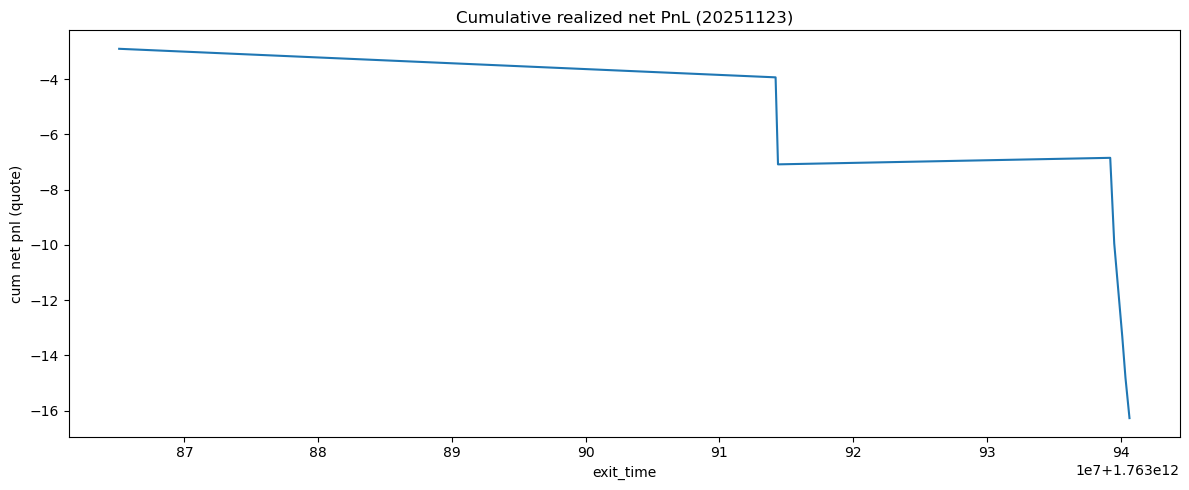

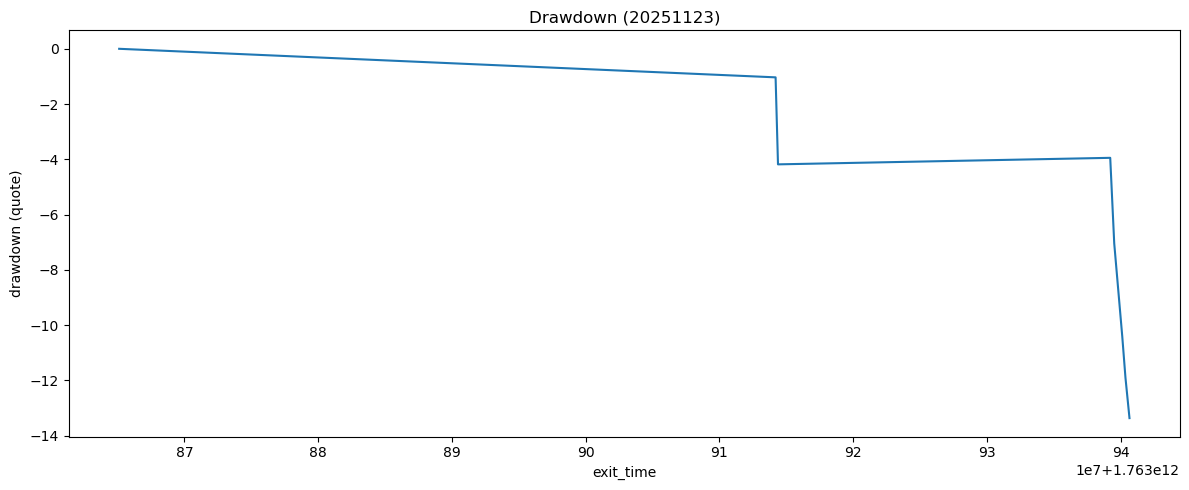

In [60]:
# =========================================
# 10. Equity curve
# =========================================

if len(trades_df) > 0:
    equity_df = trades_df.sort_values("exit_time").copy()
    equity_df["cum_pnl_quote_net"] = equity_df["pnl_quote_net"].cumsum()
    equity_df["running_max"] = equity_df["cum_pnl_quote_net"].cummax()
    equity_df["drawdown_quote"] = equity_df["cum_pnl_quote_net"] - equity_df["running_max"]

    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.plot(equity_df["exit_time"], equity_df["cum_pnl_quote_net"])
    ax.set_title(f"Cumulative realized net PnL ({TARGET_DATE})")
    ax.set_xlabel("exit_time")
    ax.set_ylabel("cum net pnl (quote)")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.plot(equity_df["exit_time"], equity_df["drawdown_quote"])
    ax.set_title(f"Drawdown ({TARGET_DATE})")
    ax.set_xlabel("exit_time")
    ax.set_ylabel("drawdown (quote)")
    plt.tight_layout()
    plt.show()

# 11. Session-level PnL

,entry_session_id,n_trades,total_pnl_quote_net,avg_trade_pnl_quote_net,win_rate_net
0,20251123_02,1,-2.900221,-2.900221,0.0
1,20251123_16,2,-4.183301,-2.091651,0.0
2,20251123_23,5,-9.186223,-1.837245,0.2


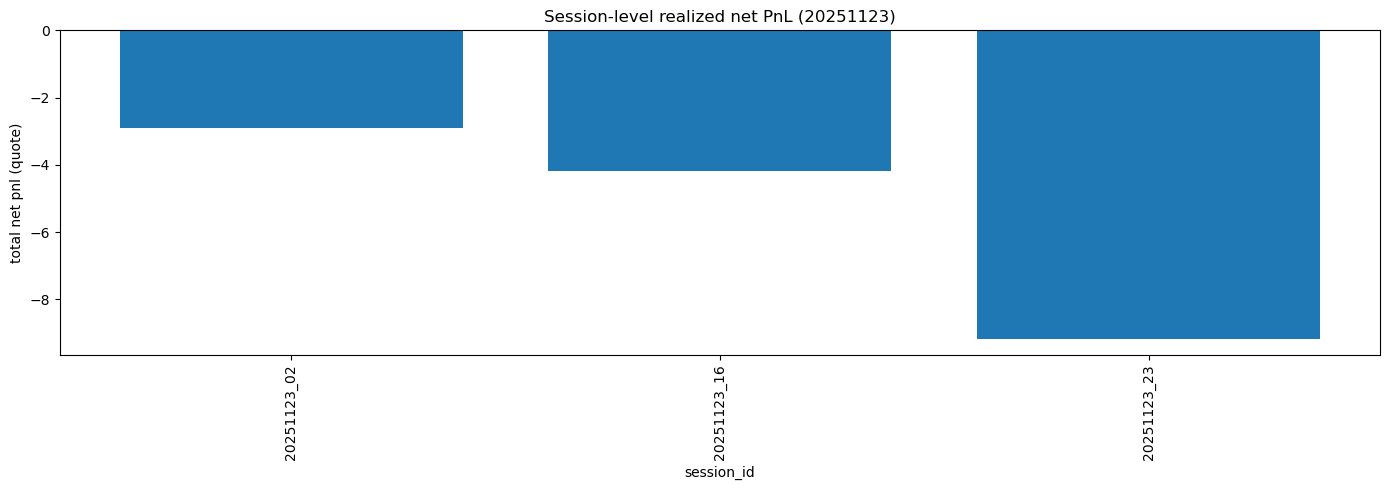

In [61]:
# =========================================
# 11. Session-level summary
# =========================================

if len(trades_df) > 0:
    session_pnl = trades_df.groupby("entry_session_id").agg(
        n_trades=("pnl_quote_net", "size"),
        total_pnl_quote_net=("pnl_quote_net", "sum"),
        avg_trade_pnl_quote_net=("pnl_quote_net", "mean"),
        win_rate_net=("pnl_quote_net", lambda x: (x > 0).mean()),
    ).reset_index()

    display(session_pnl.head(20))

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(session_pnl["entry_session_id"], session_pnl["total_pnl_quote_net"])
    ax.set_title(f"Session-level realized net PnL ({TARGET_DATE})")
    ax.set_xlabel("session_id")
    ax.set_ylabel("total net pnl (quote)")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

# 12. Strategy-level size sweep

This is the first-pass capacity view:
rerun the execution-aware backtest for multiple fixed notionals.

In [62]:
# =========================================
# 12. Size sweep
# =========================================

SIZE_GRID = [250, 500, 1000, 2500, 5000]

In [63]:
# =========================================
# 12b. Run size sweep
# =========================================

size_sweep_rows = []

for notional in SIZE_GRID:
    trades_tmp, _ = simulate_execution_aware_trades(
        actions_df=trade_actions,
        trade_notional=notional,
        top_n=TOP_N,
        taker_fee_bps=TAKER_FEE_BPS,
    )

    if len(trades_tmp) == 0:
        size_sweep_rows.append({
            "trade_notional": notional,
            "n_trades": 0,
            "total_pnl_quote_net": np.nan,
            "avg_trade_pnl_quote_net": np.nan,
            "win_rate_net": np.nan,
        })
    else:
        size_sweep_rows.append({
            "trade_notional": notional,
            "n_trades": len(trades_tmp),
            "total_pnl_quote_net": trades_tmp["pnl_quote_net"].sum(),
            "avg_trade_pnl_quote_net": trades_tmp["pnl_quote_net"].mean(),
            "win_rate_net": (trades_tmp["pnl_quote_net"] > 0).mean(),
        })

size_sweep_df = pd.DataFrame(size_sweep_rows)
display(size_sweep_df)

,trade_notional,n_trades,total_pnl_quote_net,avg_trade_pnl_quote_net,win_rate_net
0,250,8,-4.055992,-0.506999,0.125
1,500,8,-8.123349,-1.015419,0.125
2,1000,8,-16.269745,-2.033718,0.125
3,2500,8,-38.275394,-4.784424,0.125
4,5000,8,-73.913610,-9.239201,0.125


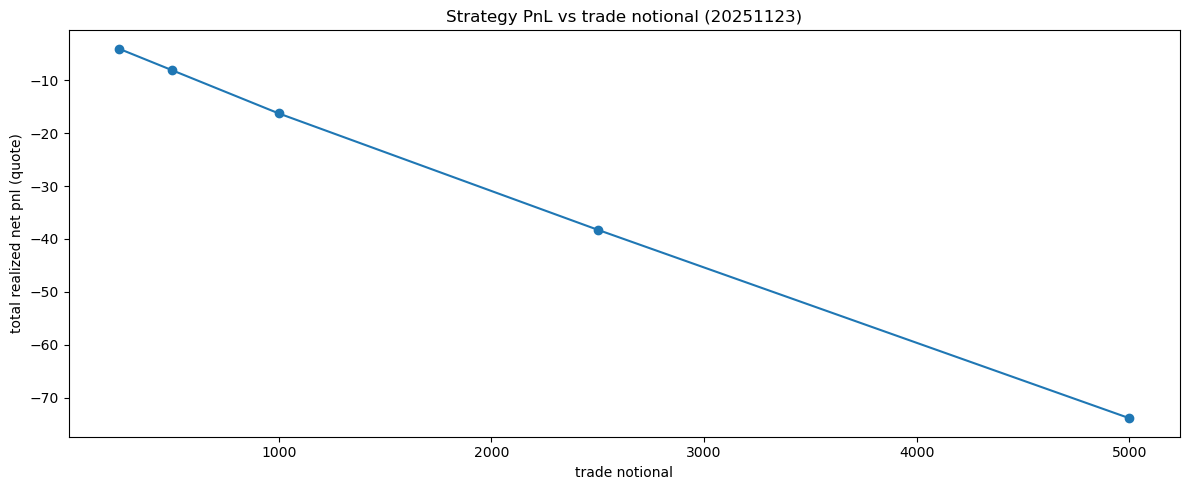

In [64]:
# =========================================
# 12c. Plot size sensitivity
# =========================================

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(size_sweep_df["trade_notional"], size_sweep_df["total_pnl_quote_net"], marker="o")
ax.set_title(f"Strategy PnL vs trade notional ({TARGET_DATE})")
ax.set_xlabel("trade notional")
ax.set_ylabel("total realized net pnl (quote)")
plt.tight_layout()
plt.show()

In [65]:
# 13. Save outputs

In [66]:
# =========================================
# 13. Save outputs
# =========================================

if len(trades_df) > 0:
    trades_df.to_parquet(BACKTEST_OUTPUT_ROOT / f"execution_aware_trades_{TARGET_DATE}.parquet", index=False)

if len(fills_df) > 0:
    fills_df.to_parquet(BACKTEST_OUTPUT_ROOT / f"execution_aware_fills_{TARGET_DATE}.parquet", index=False)

if "equity_df" in locals() and len(equity_df) > 0:
    equity_df.to_parquet(BACKTEST_OUTPUT_ROOT / f"execution_aware_equity_{TARGET_DATE}.parquet", index=False)

size_sweep_df.to_parquet(BACKTEST_OUTPUT_ROOT / f"execution_aware_size_sweep_{TARGET_DATE}.parquet", index=False)

print("Saved outputs to:", BACKTEST_OUTPUT_ROOT)

Saved outputs to: /Volumes/profit/bitcoin_ticks/backtest_outputs


# 14. Summary

This notebook provides a first-pass execution-aware strategy backtest.

It answers:

- how many strategy signals become actual trades?
- what realized after-cost PnL survives after realistic execution?
- how sensitive is performance to fixed notional trade size?
- which sessions contribute most to performance?

## Next extensions

1. multiple-day backtest
2. more exact strategy/export consistency with research notebook
3. more exact vol-filter threshold logic
4. latency / staleness assumptions
5. later: passive / maker execution assumptions

# 15. Post-backtest diagnosis

This section diagnoses **why** the execution-aware backtest behaved the way it did.

Main questions:

1. Which trades were gross-profitable but net-unprofitable?
2. Is the main pain coming from fees, exit execution, or both?
3. Are long and short trades asymmetric?
4. Are some sessions consistently worse than others?

In [67]:
# =========================================
# 15a. Trade-level diagnosis table
# =========================================

if len(trades_df) > 0:
    diag_cols = [
        "entry_time",
        "exit_time",
        "entry_session_id",
        "direction",
        "entry_qty",
        "entry_price",
        "exit_price",
        "entry_levels_swept",
        "exit_levels_swept",
        "entry_fee_quote",
        "exit_fee_quote",
        "pnl_quote_gross",
        "pnl_quote_net",
    ]

    trade_diag_df = trades_df[diag_cols].copy()

    trade_diag_df["fee_drag_quote"] = (
        trade_diag_df["pnl_quote_gross"] - trade_diag_df["pnl_quote_net"]
    )
    trade_diag_df["gross_positive_net_negative"] = (
        (trade_diag_df["pnl_quote_gross"] > 0) &
        (trade_diag_df["pnl_quote_net"] < 0)
    )

    display(trade_diag_df.head(20))

,entry_time,exit_time,entry_session_id,direction,entry_qty,entry_price,exit_price,entry_levels_swept,exit_levels_swept,entry_fee_quote,exit_fee_quote,pnl_quote_gross,pnl_quote_net,fee_drag_quote,gross_positive_net_negative
0,1763865000214,1763865120514,20251123_02,short,0.011622,86042.62,86120.000000,1,1,1.0,1.000899,-0.899322,-2.900221,2.000899,False
1,1763914140114,1763914200114,20251123_16,short,0.011447,87358.72,87274.380000,1,1,1.0,0.999034,0.965444,-1.033590,1.999034,True
2,1763914260214,1763914380514,20251123_16,long,0.011464,87229.58,87129.190806,1,11,1.0,0.998849,-1.150862,-3.149711,1.998849,False
3,1763939052114,1763939220514,20251123_23,short,0.011405,87677.07,87481.187271,1,8,1.0,0.997766,2.234139,0.236373,1.997766,False
4,1763939460914,1763939520114,20251123_23,long,0.011414,87614.09,87517.786157,1,4,1.0,0.998901,-1.099182,-3.098083,1.998901,False
5,1763940000514,1763940120614,20251123_23,long,0.011484,87077.91,86958.630000,1,1,1.0,0.998630,-1.369808,-3.368438,1.998630,False
6,1763940300114,1763940360214,20251123_23,short,0.011493,87009.55,86965.610000,1,1,1.0,0.999495,0.505002,-1.494493,1.999495,True
7,1763940600214,1763940660614,20251123_23,short,0.011486,87064.03,87017.200000,1,1,1.0,0.999462,0.537880,-1.461582,1.999462,True


In [68]:
# =========================================
# 15b. Gross vs net summary
# =========================================

if len(trades_df) > 0:
    gross_net_summary = pd.Series({
        "n_trades": len(trades_df),
        "total_gross_pnl": trades_df["pnl_quote_gross"].sum(),
        "total_net_pnl": trades_df["pnl_quote_net"].sum(),
        "total_fee_drag": (trades_df["pnl_quote_gross"] - trades_df["pnl_quote_net"]).sum(),
        "avg_fee_drag_per_trade": (trades_df["pnl_quote_gross"] - trades_df["pnl_quote_net"]).mean(),
        "n_gross_positive": (trades_df["pnl_quote_gross"] > 0).sum(),
        "n_net_positive": (trades_df["pnl_quote_net"] > 0).sum(),
        "n_gross_positive_net_negative": (
            (trades_df["pnl_quote_gross"] > 0) &
            (trades_df["pnl_quote_net"] < 0)
        ).sum(),
    })
    display(gross_net_summary)

n_trades                          8.000000
total_gross_pnl                  -0.276709
total_net_pnl                   -16.269745
total_fee_drag                   15.993037
avg_fee_drag_per_trade            1.999130
n_gross_positive                  4.000000
n_net_positive                    1.000000
n_gross_positive_net_negative     3.000000
dtype: float64

In [69]:
# =========================================
# 15c. Trades sorted by net pnl
# =========================================

if len(trades_df) > 0:
    worst_trades = trades_df.sort_values("pnl_quote_net").copy()
    display(
        worst_trades[[
            "entry_session_id",
            "direction",
            "entry_time",
            "exit_time",
            "entry_levels_swept",
            "exit_levels_swept",
            "entry_fee_quote",
            "exit_fee_quote",
            "pnl_quote_gross",
            "pnl_quote_net",
        ]].head(10)
    )

    best_trades = trades_df.sort_values("pnl_quote_net", ascending=False).copy()
    display(
        best_trades[[
            "entry_session_id",
            "direction",
            "entry_time",
            "exit_time",
            "entry_levels_swept",
            "exit_levels_swept",
            "entry_fee_quote",
            "exit_fee_quote",
            "pnl_quote_gross",
            "pnl_quote_net",
        ]].head(10)
    )

,entry_session_id,direction,entry_time,exit_time,entry_levels_swept,exit_levels_swept,entry_fee_quote,exit_fee_quote,pnl_quote_gross,pnl_quote_net
5,20251123_23,long,1763940000514,1763940120614,1,1,1.0,0.998630,-1.369808,-3.368438
2,20251123_16,long,1763914260214,1763914380514,1,11,1.0,0.998849,-1.150862,-3.149711
4,20251123_23,long,1763939460914,1763939520114,1,4,1.0,0.998901,-1.099182,-3.098083
0,20251123_02,short,1763865000214,1763865120514,1,1,1.0,1.000899,-0.899322,-2.900221
6,20251123_23,short,1763940300114,1763940360214,1,1,1.0,0.999495,0.505002,-1.494493
7,20251123_23,short,1763940600214,1763940660614,1,1,1.0,0.999462,0.537880,-1.461582
1,20251123_16,short,1763914140114,1763914200114,1,1,1.0,0.999034,0.965444,-1.033590
3,20251123_23,short,1763939052114,1763939220514,1,8,1.0,0.997766,2.234139,0.236373


,entry_session_id,direction,entry_time,exit_time,entry_levels_swept,exit_levels_swept,entry_fee_quote,exit_fee_quote,pnl_quote_gross,pnl_quote_net
3,20251123_23,short,1763939052114,1763939220514,1,8,1.0,0.997766,2.234139,0.236373
1,20251123_16,short,1763914140114,1763914200114,1,1,1.0,0.999034,0.965444,-1.033590
7,20251123_23,short,1763940600214,1763940660614,1,1,1.0,0.999462,0.537880,-1.461582
6,20251123_23,short,1763940300114,1763940360214,1,1,1.0,0.999495,0.505002,-1.494493
0,20251123_02,short,1763865000214,1763865120514,1,1,1.0,1.000899,-0.899322,-2.900221
4,20251123_23,long,1763939460914,1763939520114,1,4,1.0,0.998901,-1.099182,-3.098083
2,20251123_16,long,1763914260214,1763914380514,1,11,1.0,0.998849,-1.150862,-3.149711
5,20251123_23,long,1763940000514,1763940120614,1,1,1.0,0.998630,-1.369808,-3.368438


# 16. Directional asymmetry

Check whether long and short trades behave differently in:

- gross pnl
- net pnl
- win rate
- entry / exit execution stress

In [70]:
# =========================================
# 16a. Long vs short asymmetry summary
# =========================================

if len(trades_df) > 0:
    asym_dir = trades_df.groupby("direction").agg(
        n_trades=("direction", "size"),
        total_gross_pnl=("pnl_quote_gross", "sum"),
        total_net_pnl=("pnl_quote_net", "sum"),
        avg_gross_pnl=("pnl_quote_gross", "mean"),
        avg_net_pnl=("pnl_quote_net", "mean"),
        median_net_pnl=("pnl_quote_net", "median"),
        win_rate_net=("pnl_quote_net", lambda x: (x > 0).mean()),
        avg_entry_levels_swept=("entry_levels_swept", "mean"),
        avg_exit_levels_swept=("exit_levels_swept", "mean"),
        avg_entry_fee=("entry_fee_quote", "mean"),
        avg_exit_fee=("exit_fee_quote", "mean"),
        avg_holding_seconds=("holding_seconds", "mean"),
    ).reset_index()

    display(asym_dir)

,direction,n_trades,total_gross_pnl,total_net_pnl,avg_gross_pnl,avg_net_pnl,median_net_pnl,win_rate_net,avg_entry_levels_swept,avg_exit_levels_swept,avg_entry_fee,avg_exit_fee,avg_holding_seconds
0,long,3,-3.619852,-9.616232,-1.206617,-3.205411,-3.149711,0.0,1.0,5.333333,1.0,0.998793,99.866667
1,short,5,3.343143,-6.653513,0.668629,-1.330703,-1.461582,0.2,1.0,2.400000,1.0,0.999331,93.840000


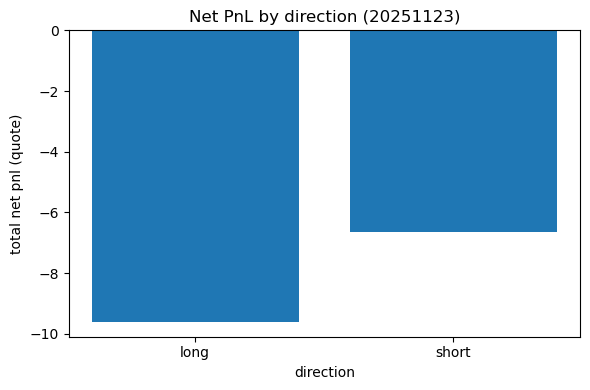

In [71]:
# =========================================
# 16b. Plot long vs short net pnl
# =========================================

if len(trades_df) > 0:
    asym_plot = trades_df.groupby("direction")["pnl_quote_net"].sum().reset_index()

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(asym_plot["direction"], asym_plot["pnl_quote_net"])
    ax.set_title(f"Net PnL by direction ({TARGET_DATE})")
    ax.set_xlabel("direction")
    ax.set_ylabel("total net pnl (quote)")
    plt.tight_layout()
    plt.show()

# 17. Entry vs exit execution stress

This checks whether exit execution is systematically more painful than entry execution.

In [73]:
# =========================================
# 17a. Entry vs exit stress summary
# =========================================

if len(trades_df) > 0:
    entry_exit_summary = pd.Series({
        "avg_entry_levels_swept": trades_df["entry_levels_swept"].mean(),
        "avg_exit_levels_swept": trades_df["exit_levels_swept"].mean(),
        "median_entry_levels_swept": trades_df["entry_levels_swept"].median(),
        "median_exit_levels_swept": trades_df["exit_levels_swept"].median(),
        "p90_exit_levels_swept": trades_df["exit_levels_swept"].quantile(0.90),
        "avg_entry_fee_quote": trades_df["entry_fee_quote"].mean(),
        "avg_exit_fee_quote": trades_df["exit_fee_quote"].mean(),
    })
    display(entry_exit_summary)

avg_entry_levels_swept       1.00000
avg_exit_levels_swept        3.50000
median_entry_levels_swept    1.00000
median_exit_levels_swept     1.00000
p90_exit_levels_swept        8.90000
avg_entry_fee_quote          1.00000
avg_exit_fee_quote           0.99913
dtype: float64

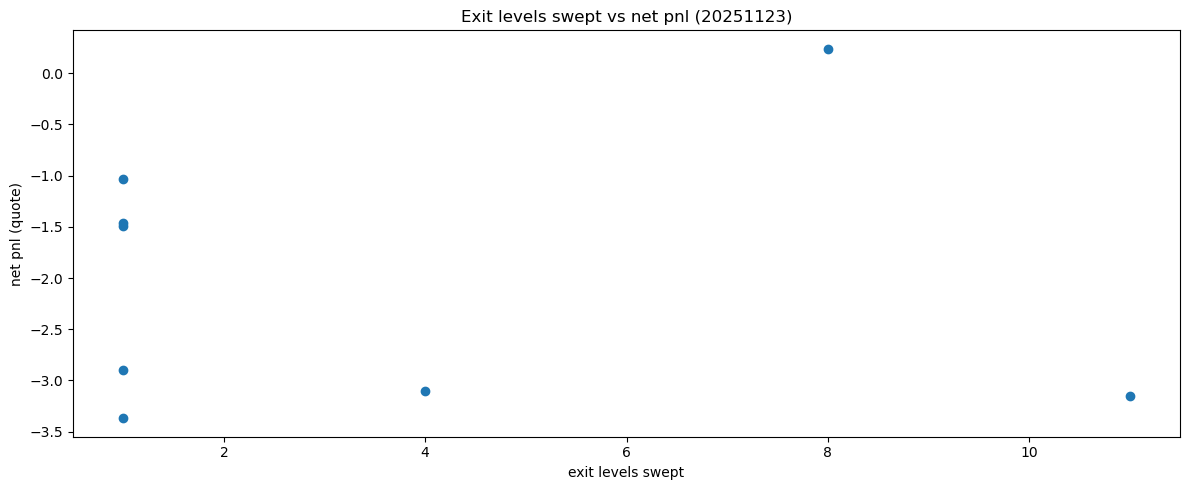

In [74]:
# =========================================
# 17b. Scatter: exit levels swept vs net pnl
# =========================================

if len(trades_df) > 0:
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.scatter(trades_df["exit_levels_swept"], trades_df["pnl_quote_net"])
    ax.set_title(f"Exit levels swept vs net pnl ({TARGET_DATE})")
    ax.set_xlabel("exit levels swept")
    ax.set_ylabel("net pnl (quote)")
    plt.tight_layout()
    plt.show()

# 18. Session-level diagnosis

Identify whether certain hours / sessions are much better or worse.

In [75]:
# =========================================
# 18a. Session-level diagnosis
# =========================================

if len(trades_df) > 0:
    session_diag = trades_df.groupby("entry_session_id").agg(
        n_trades=("pnl_quote_net", "size"),
        total_gross_pnl=("pnl_quote_gross", "sum"),
        total_net_pnl=("pnl_quote_net", "sum"),
        avg_net_pnl=("pnl_quote_net", "mean"),
        median_net_pnl=("pnl_quote_net", "median"),
        win_rate_net=("pnl_quote_net", lambda x: (x > 0).mean()),
        avg_entry_levels_swept=("entry_levels_swept", "mean"),
        avg_exit_levels_swept=("exit_levels_swept", "mean"),
    ).reset_index()

    display(session_diag.sort_values("total_net_pnl"))

,entry_session_id,n_trades,total_gross_pnl,total_net_pnl,avg_net_pnl,median_net_pnl,win_rate_net,avg_entry_levels_swept,avg_exit_levels_swept
2,20251123_23,5,0.808030,-9.186223,-1.837245,-1.494493,0.2,1.0,3.0
1,20251123_16,2,-0.185417,-4.183301,-2.091651,-2.091651,0.0,1.0,6.0
0,20251123_02,1,-0.899322,-2.900221,-2.900221,-2.900221,0.0,1.0,1.0


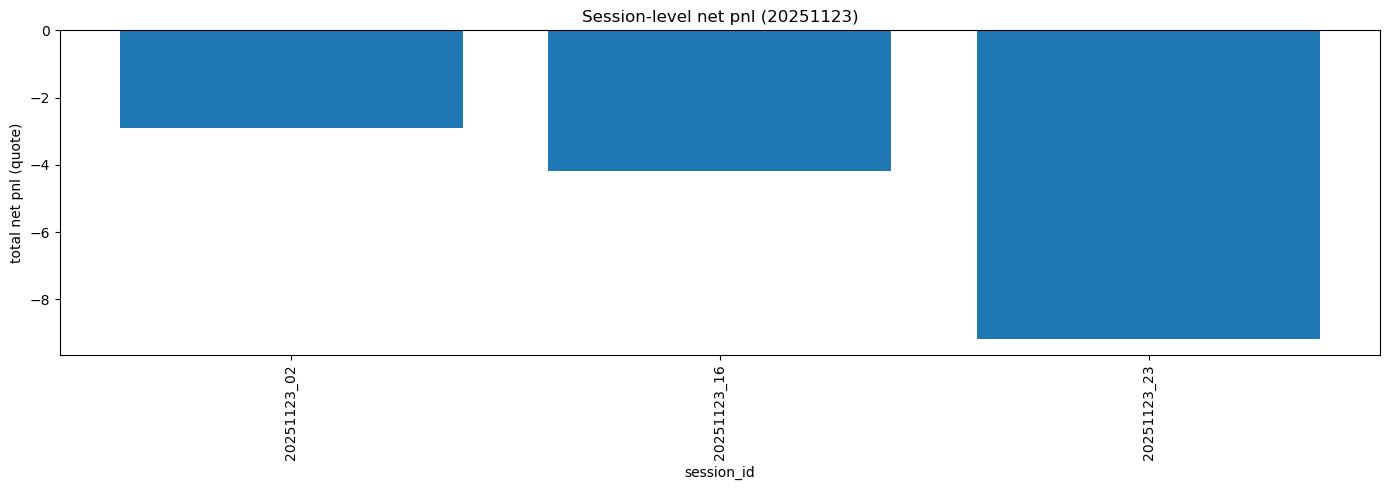

In [76]:
# =========================================
# 18b. Plot session net pnl
# =========================================

if len(trades_df) > 0:
    session_diag_plot = session_diag.sort_values("entry_session_id").copy()

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(session_diag_plot["entry_session_id"], session_diag_plot["total_net_pnl"])
    ax.set_title(f"Session-level net pnl ({TARGET_DATE})")
    ax.set_xlabel("session_id")
    ax.set_ylabel("total net pnl (quote)")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

# 19. Signal-strength diagnosis

Before introducing strength-based sizing, check whether stronger signals are actually associated with better trade outcomes.

In [77]:
# =========================================
# 19a. Attach entry-time signal strength to trades
# =========================================

if len(trades_df) > 0 and len(trade_actions) > 0:
    entry_strength_map = trade_actions[[
        "event_time",
        "basis_z",
        "raw_basis_signal",
        "signal",
        "pred_vol_30m",
    ]].copy()

    entry_strength_map = entry_strength_map.rename(columns={
        "event_time": "entry_time",
        "basis_z": "entry_basis_z",
        "raw_basis_signal": "entry_raw_basis_signal",
        "signal": "entry_signal_state",
        "pred_vol_30m": "entry_pred_vol_30m",
    })

    trades_diag_strength = trades_df.merge(
        entry_strength_map,
        on="entry_time",
        how="left",
    )

    trades_diag_strength["abs_entry_basis_z"] = trades_diag_strength["entry_basis_z"].abs()

    display(trades_diag_strength[[
        "entry_session_id",
        "direction",
        "entry_time",
        "entry_basis_z",
        "abs_entry_basis_z",
        "pnl_quote_gross",
        "pnl_quote_net",
        "entry_levels_swept",
        "exit_levels_swept",
    ]].head(20))

,entry_session_id,direction,entry_time,entry_basis_z,abs_entry_basis_z,pnl_quote_gross,pnl_quote_net,entry_levels_swept,exit_levels_swept
0,20251123_02,short,1763865000214,3.956125,3.956125,-0.899322,-2.900221,1,1
1,20251123_16,short,1763914140114,1.751659,1.751659,0.965444,-1.033590,1,1
2,20251123_16,long,1763914260214,-3.148323,3.148323,-1.150862,-3.149711,1,11
3,20251123_23,short,1763939052114,3.691438,3.691438,2.234139,0.236373,1,8
4,20251123_23,long,1763939460914,-1.844268,1.844268,-1.099182,-3.098083,1,4
5,20251123_23,long,1763940000514,-1.530415,1.530415,-1.369808,-3.368438,1,1
6,20251123_23,short,1763940300114,1.512814,1.512814,0.505002,-1.494493,1,1
7,20251123_23,short,1763940600214,2.320107,2.320107,0.537880,-1.461582,1,1


In [80]:
# =========================================
# 19b. Bucket trades by entry signal strength
# =========================================

if "trades_diag_strength" in locals() and len(trades_diag_strength) > 0:
    bins = [0, ENTRY_Z, 2.0, STRONG_Z, np.inf]
    labels = ["below_entry", "entry_to_2.0", "2.0_to_strong", "strong_plus"]

    trades_diag_strength["strength_bucket"] = pd.cut(
        trades_diag_strength["abs_entry_basis_z"],
        bins=bins,
        labels=labels,
        include_lowest=True,
        right=False,
    )

    strength_summary = trades_diag_strength.groupby("strength_bucket", observed=False).agg(
        n_trades=("pnl_quote_net", "size"),
        total_gross_pnl=("pnl_quote_gross", "sum"),
        total_net_pnl=("pnl_quote_net", "sum"),
        avg_net_pnl=("pnl_quote_net", "mean"),
        median_net_pnl=("pnl_quote_net", "median"),
        win_rate_net=("pnl_quote_net", lambda x: (x > 0).mean()),
        avg_entry_levels_swept=("entry_levels_swept", "mean"),
        avg_exit_levels_swept=("exit_levels_swept", "mean"),
    ).reset_index()

    display(strength_summary)

,strength_bucket,n_trades,total_gross_pnl,total_net_pnl,avg_net_pnl,median_net_pnl,win_rate_net,avg_entry_levels_swept,avg_exit_levels_swept
0,below_entry,0,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
1,entry_to_2.0,4,-0.998544,-8.994604,-2.248651,-2.296288,0.000000,1.0,1.750000
2,2.0_to_strong,1,0.537880,-1.461582,-1.461582,-1.461582,0.000000,1.0,1.000000
3,strong_plus,3,0.183955,-5.813559,-1.937853,-2.900221,0.333333,1.0,6.666667


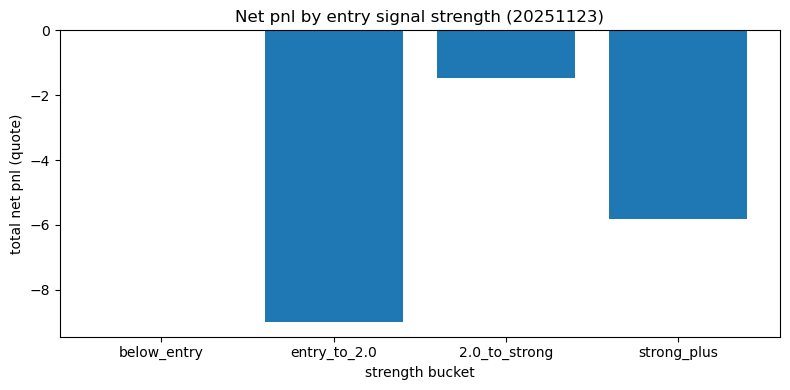

In [81]:
# =========================================
# 19c. Plot net pnl by strength bucket
# =========================================

if "strength_summary" in locals() and len(strength_summary) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(strength_summary["strength_bucket"].astype(str), strength_summary["total_net_pnl"])
    ax.set_title(f"Net pnl by entry signal strength ({TARGET_DATE})")
    ax.set_xlabel("strength bucket")
    ax.set_ylabel("total net pnl (quote)")
    plt.tight_layout()
    plt.show()